# Experiment 8.1 — Hidden quantization ablation

Analysis-only notebook for the finalized Exp8.1 artifacts. The experiment compares binary communication, cap-31 weighted multi-spike communication, and fixed heterogeneous-threshold binary populations under the Exp7.3 A2 training contract.


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
ART = ROOT / "notebooks" / "artifacts" / "experiment_8_1_hidden_quantization_ablation" / "hidden_quantization_ablation_v1"

manifest = json.loads((ART / "manifest.json").read_text())
runs = pd.read_csv(ART / "method_runs.csv")
summary = pd.read_csv(ART / "method_summary.csv")
contrasts = pd.read_csv(ART / "contrast_summary.csv")
activity = pd.read_csv(ART / "activity_summary.csv")
manifest


{'counts': {'methods': 5, 'parallel_runs': 15, 'seeds': 3},
 'diagnostics': {'aggregations': ['whole_mean', 'fixed250_ordered_mean'],
  'states': ['pre_reset', 'communication']},
 'experiment_id': 'experiment_8_1_hidden_quantization_ablation',
 'hidden_shifts': [2, 3, 4],
 'l2_width': 128,
 'method_order': ['binary128',
  'weighted31_128',
  'mt3_128',
  'binary384',
  'mt3_384'],
 'methods': {'binary128': {'coding': 'binary', 'l1_width': 128},
  'binary384': {'coding': 'binary', 'l1_width': 384},
  'mt3_128': {'coding': 'hetero3', 'l1_width': 128},
  'mt3_384': {'coding': 'hetero3', 'l1_width': 384},
  'weighted31_128': {'coding': 'weighted31', 'l1_width': 128}},
 'primary_metric': 'linear_test_ba',
 'protocol_version': 'hidden_quantization_ablation_v1',
 'scope': 'L1 coding/width only; L2 remains 128-neuron binary (234)',
 'seeds': [11, 23, 37],
 'threshold': 0.5,
 'threshold_multipliers': [0.5, 1.0, 1.5],
 'training': 'Exp7.3 A2-compatible end-to-end Linear/WCCE',
 'weighted_hidden_

## Method-level results

The primary endpoint is native Linear/WCCE test balanced accuracy. L1/L2 Fixed250 probes show whether a communication code preserves local temporal information, while the quantization gap compares pre-reset membrane information with the value actually transmitted to the next layer.


In [2]:
cols = [
    "method", "linear_test_ba_mean", "linear_test_ba_std",
    "l1_pre_reset_fixed250_ba_mean", "l1_communication_fixed250_ba_mean",
    "l1_quantization_gap_fixed250_mean",
    "l2_pre_reset_fixed250_ba_mean", "l2_communication_fixed250_ba_mean",
]
summary[[c for c in cols if c in summary.columns]]


,method,linear_test_ba_mean,linear_test_ba_std,l1_pre_reset_fixed250_ba_mean,l1_communication_fixed250_ba_mean,l1_quantization_gap_fixed250_mean,l2_pre_reset_fixed250_ba_mean,l2_communication_fixed250_ba_mean
0,binary128,0.564502,0.032830,0.623111,0.534067,0.089044,0.589742,0.618353
1,weighted31_128,0.541649,0.038476,0.613246,0.537683,0.075563,0.575134,0.595031
2,mt3_128,0.534664,0.011586,0.624587,0.567509,0.057077,0.580566,0.593620
3,binary384,0.572312,0.057910,0.631140,0.529035,0.102106,0.568784,0.645772
4,mt3_384,0.573928,0.009789,0.649478,0.586608,0.062870,0.584954,0.639291


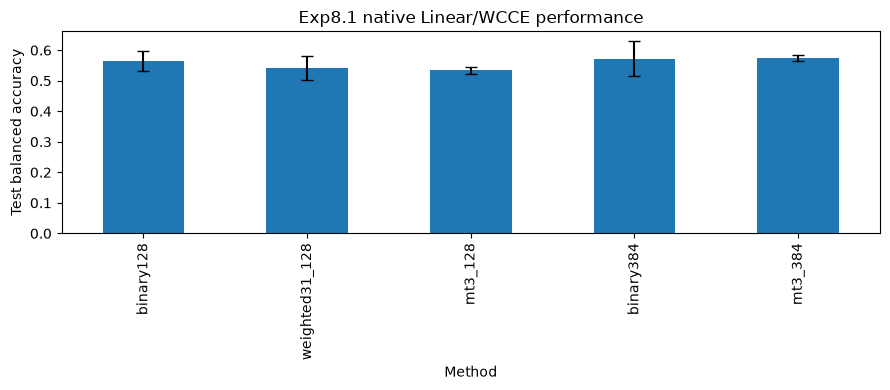

In [3]:
order = manifest["method_order"]
plot_df = runs.groupby("method", sort=False)["linear_test_ba"].agg(["mean", "std"]).reindex(order)
ax = plot_df["mean"].plot(kind="bar", yerr=plot_df["std"], capsize=4, figsize=(9, 4))
ax.set_ylabel("Test balanced accuracy")
ax.set_xlabel("Method")
ax.set_title("Exp8.1 native Linear/WCCE performance")
plt.tight_layout()
plt.show()


## Quantization-gap view


In [4]:
gap = runs.groupby("method", sort=False)[[
    "l1_pre_reset_fixed250_ba",
    "l1_communication_fixed250_ba",
    "l1_quantization_gap_fixed250",
]].mean().reindex(manifest["method_order"])
gap


,l1_pre_reset_fixed250_ba,l1_communication_fixed250_ba,l1_quantization_gap_fixed250
method,,,
binary128,0.623111,0.534067,0.089044
weighted31_128,0.613246,0.537683,0.075563
mt3_128,0.624587,0.567509,0.057077
binary384,0.631140,0.529035,0.102106
mt3_384,0.649478,0.586608,0.062870


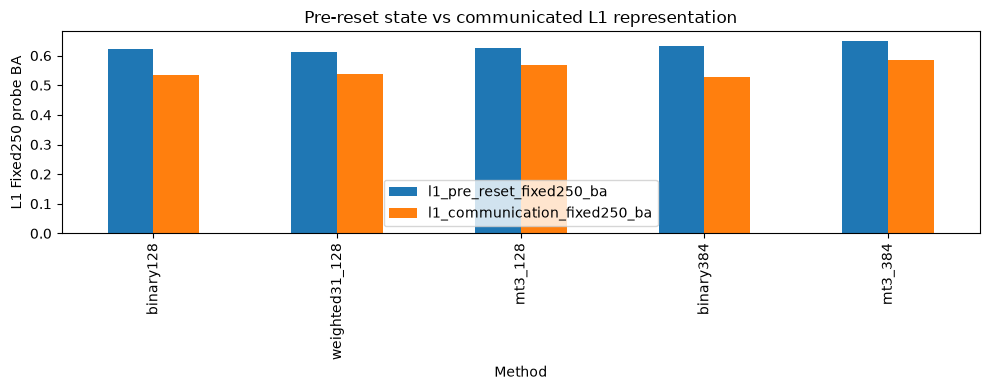

In [5]:
ax = gap[["l1_pre_reset_fixed250_ba", "l1_communication_fixed250_ba"]].plot(kind="bar", figsize=(10, 4))
ax.set_ylabel("L1 Fixed250 probe BA")
ax.set_xlabel("Method")
ax.set_title("Pre-reset state vs communicated L1 representation")
plt.tight_layout()
plt.show()


## Paired contrasts

These contrasts separate event-resolution, threshold-heterogeneity, and pure-width effects.


In [6]:
contrast_cols = [c for c in contrasts.columns if c in {"contrast", "method_a", "method_b"} or c.startswith("delta_linear_test_ba") or c.startswith("delta_l1_communication_fixed250_ba") or c.startswith("delta_l1_quantization_gap_fixed250")]
contrasts[contrast_cols]


,contrast,method_a,method_b,delta_linear_test_ba_mean,delta_linear_test_ba_std,delta_l1_communication_fixed250_ba_mean,delta_l1_communication_fixed250_ba_std,delta_l1_quantization_gap_fixed250_mean,delta_l1_quantization_gap_fixed250_std
0,weighted_vs_binary_128,weighted31_128,binary128,-0.022853,0.010191,0.003616,0.010926,-0.013481,0.015547
1,mt_vs_binary_128,mt3_128,binary128,-0.029838,0.042957,0.033442,0.014431,-0.031967,0.017798
2,mt_vs_weighted_128,mt3_128,weighted31_128,-0.006985,0.047101,0.029827,0.022212,-0.018486,0.033081
3,width_binary_384_vs_128,binary384,binary128,0.007810,0.055303,-0.005032,0.027990,0.013061,0.057173
4,width_mt_384_vs_128,mt3_384,mt3_128,0.039265,0.020715,0.019099,0.021090,0.005793,0.013572
5,mt_vs_binary_384,mt3_384,binary384,0.001616,0.054306,0.057574,0.025169,-0.039236,0.056920


## Activity by threshold/tau group


In [7]:
activity.head(30)


,method,layer,threshold_multiplier,shift,mean_value_per_neuron_step_mean,mean_value_per_neuron_step_std,fraction_nonzero_mean,fraction_nonzero_std,fraction_gt1_mean,fraction_gt1_std,fraction_at_cap_mean,fraction_at_cap_std
0,binary128,l1,1.0,2,0.007565,0.000122,0.007565,0.000122,0.000000,0.000000,0.007565,0.000122
1,binary128,l1,1.0,3,0.027848,0.006130,0.027848,0.006130,0.000000,0.000000,0.027848,0.006130
2,binary128,l1,1.0,4,0.132345,0.006787,0.132345,0.006787,0.000000,0.000000,0.132345,0.006787
3,binary128,l2,1.0,2,0.348633,0.006064,0.348633,0.006064,0.000000,0.000000,0.348633,0.006064
4,binary128,l2,1.0,3,0.365308,0.018241,0.365308,0.018241,0.000000,0.000000,0.365308,0.018241
5,binary128,l2,1.0,4,0.380766,0.009471,0.380766,0.009471,0.000000,0.000000,0.380766,0.009471
6,weighted31_128,l1,1.0,2,0.007544,0.001082,0.007525,0.001084,0.000019,0.000013,0.000000,0.000000
7,weighted31_128,l1,1.0,3,0.028807,0.007094,0.028709,0.007018,0.000098,0.000079,0.000000,0.000000
8,weighted31_128,l1,1.0,4,0.135926,0.008939,0.130828,0.008818,0.005065,0.001014,0.000000,0.000000
9,weighted31_128,l2,1.0,2,0.352013,0.017899,0.352013,0.017899,0.000000,0.000000,0.352013,0.017899
